# 05. Hotspot vs Non-hotspot Analysis

본 단계에서는 04장의 공간 분석에서 식별한 사고 집중 권역과 그 외 지역의 구조적 차이를 비교한다.

분석 목적은 다음과 같다.

1. 사고 집중 권역과 일반 지역의 주요 특성 차이를 확인
2. 어떤 도시·교통·보행 환경이 사고 집중과 연결되는지 탐색
3. 이후 리스크 스코어 해석 및 정책 제안의 근거 확보

본 분석에서는 04장에서 DBSCAN을 통해 탐지한 사고 집중 권역(cluster)을 hotspot의 대체 개념으로 사용한다.

In [1]:
# 필요한 라이브러리 및 기본 설정
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from shapely import wkt
from shapely.geometry.base import BaseGeometry

sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="notebook",
    font_scale=1.15
)

plt.rcParams["figure.figsize"] = (10, 6)
mpl.rcParams["axes.unicode_minus"] = False

In [2]:
# 데이터 불러오기 
# 전체 feature / high Accident DBSCAN 결과
base_path = "../outputs/processed/02_train_base_final_features.csv"
cluster_path = "../outputs/processed/04_high_accident_dbscan_result.csv"

df = pd.read_csv(base_path)
cluster_df = pd.read_csv(cluster_path)

print(df.shape)
print(cluster_df.shape)

(105032, 28)
(2877, 32)


In [3]:
# geometry (지도 다시 사용하기 전 변환하기)
def safe_to_geometry(x):
    if isinstance(x, BaseGeometry):
        return x
    elif isinstance(x, str):
        return wkt.loads(x)
    else:
        return None

df["geometry"] = df["geometry"].apply(safe_to_geometry)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

print(gdf.shape)
gdf.head()

(105032, 28)


,gid,city,geometry,acc_cnt,acc_binary,resident_pop,flow_pop,working_pop,visit_pop,service_pop,...,daycare_count,cctv_count,speedbump_count,blockType_main,landuse_group,is_residential,is_commercial,is_green,is_road,is_public
0,다사581304,경기도 성남시,"POLYGON ((127.02677 37.37172, 127.02677 37.372...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
1,다사581305,경기도 성남시,"POLYGON ((127.02677 37.37262, 127.02676 37.373...",0,0,0.0,0.031594,0.015572,0.016022,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
2,다사581306,경기도 성남시,"POLYGON ((127.02676 37.37352, 127.02676 37.374...",0,0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
3,다사582304,경기도 성남시,"POLYGON ((127.02790 37.37173, 127.02790 37.372...",0,0,0.0,0.022768,0.018269,0.004499,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0
4,다사582305,경기도 성남시,"POLYGON ((127.02790 37.37263, 127.02789 37.373...",0,0,0.0,0.031655,0.016485,0.015169,0.0,...,0.0,0.0,0.0,unknown,other,0,0,0,0,0


In [4]:
## hotspot 여부 만들기

# cluster != -1 -> high accident grid = Hotspot
# 나머지 = Non-hotspot
cluster_df["is_hotspot"] = np.where(cluster_df["cluster"] != -1, 1, 0)
cluster_df[["gid", "cluster", "is_hotspot"]].head()

# 전체 데이터에 붙이기
hotspot_map = cluster_df[["gid", "is_hotspot", "cluster"]].drop_duplicates()

analysis_df = gdf.merge(hotspot_map, on="gid", how="left")

analysis_df["is_hotspot"] = analysis_df["is_hotspot"].fillna(0).astype(int)
analysis_df["cluster"] = analysis_df["cluster"].fillna(-999).astype(int)

analysis_df["hotspot_group"] = np.where(
    analysis_df["is_hotspot"] == 1,
    "Hotspot",
    "Non-hotspot"
)

analysis_df["hotspot_group"].value_counts()

hotspot_group
Non-hotspot    103585
Hotspot          1447
Name: count, dtype: int64

## Hotspot 정의

본 분석에서는 04번 파일에서 사고 고위험 격자를 대상으로 수행한 DBSCAN 밀도 클러스터링 결과를 바탕으로, 실제 군집을 형성한 격자를 hotspot으로 정의하였다.

즉, 단순히 사고 건수가 높은 격자 전체를 hotspot으로 간주하지 않고, 공간적으로도 인접하여 하나의 사고 집중 권역을 형성한 격자만 hotspot으로 분류하였다.

In [5]:
# 분석에 사용할 변수 정의
pop_cols = ["resident_pop", "flow_pop", "working_pop", "visit_pop", "service_pop"]
traffic_cols = ["mean_speed", "traffic_volume", "congestion_freq", "congestion_time"]
facility_cols = [
    "crosswalk_count", "bus_stop_count", "school_count",
    "kinder_count", "daycare_count", "cctv_count", "speedbump_count"
]
landuse_cols = ["is_residential", "is_commercial", "is_green", "is_road", "is_public"]

key_compare_cols = pop_cols + traffic_cols + facility_cols + landuse_cols

In [6]:
## hot vs non-hot 기초 요약

summary_basic = analysis_df.groupby("hotspot_group").agg(
    grid_count=("gid", "count"),
    total_acc=("acc_cnt", "sum"),
    mean_acc=("acc_cnt", "mean"),
    accident_rate=("acc_binary", "mean")
).reset_index()

summary_basic

,hotspot_group,grid_count,total_acc,mean_acc,accident_rate
0,Hotspot,1447,5574,3.852108,1.000000
1,Non-hotspot,103585,8689,0.083883,0.056582


## Hotspot과 Non-hotspot의 기초 현황

먼저 hotspot과 non-hotspot의 전체 격자 수, 평균 사고 건수, 사고 발생 비율을 비교하여 두 집단 간 기본적인 차이를 확인한다.

In [7]:
# 주요 변수 평균 비교표
group_mean = analysis_df.groupby("hotspot_group")[key_compare_cols].mean().T
group_mean

hotspot_group,Hotspot,Non-hotspot
resident_pop,49.595593,6.539083
flow_pop,33.106810,1.712677
working_pop,8.838034,0.537352
visit_pop,24.268776,1.175325
service_pop,2.755620,0.141280
mean_speed,28.118731,11.460400
traffic_volume,600.683853,143.035852
congestion_freq,56.764804,15.006633
congestion_time,72.372273,18.786067
crosswalk_count,1.462336,0.115123


In [8]:
# 비율 계산으로 해석하기
group_mean["ratio_hotspot_to_non"] = (
    group_mean["Hotspot"] / group_mean["Non-hotspot"].replace(0, np.nan)
)

group_mean = group_mean.sort_values("ratio_hotspot_to_non", ascending=False)
group_mean.head(15)

hotspot_group,Hotspot,Non-hotspot,ratio_hotspot_to_non
visit_pop,24.268776,1.175325,20.648558
service_pop,2.755620,0.141280,19.504716
flow_pop,33.106810,1.712677,19.330443
working_pop,8.838034,0.537352,16.447389
is_road,0.328265,0.025718,12.764027
crosswalk_count,1.462336,0.115123,12.702395
cctv_count,0.221838,0.020640,10.747951
bus_stop_count,0.647547,0.070348,9.204902
is_commercial,0.063580,0.007047,9.021802
resident_pop,49.595593,6.539083,7.584487


## 주요 변수 평균 비교

Hotspot과 non-hotspot의 주요 변수 평균을 비교하여, 사고 집중 권역이 어떤 구조적 특성을 가지는지 확인한다.특히 사람의 이동, 차량 흐름, 보행 시설, 토지이용 특성이 hotspot에서 상대적으로 더 높게 나타나는지에 주목한다.

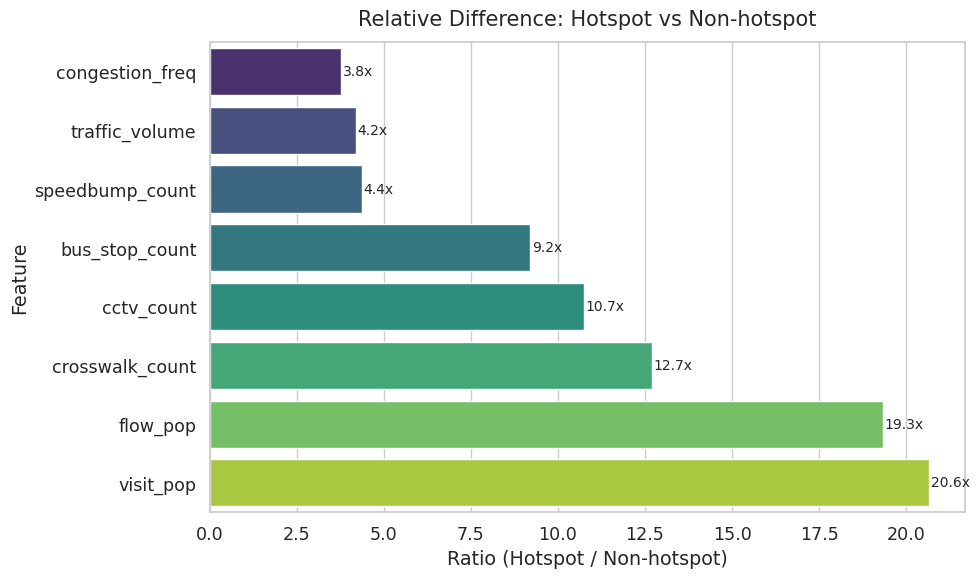

In [9]:
# 비율 시각화

plot_ratio = group_mean.loc[
    ["flow_pop", "visit_pop", "traffic_volume", "congestion_freq",
     "crosswalk_count", "bus_stop_count", "cctv_count", "speedbump_count"],
    "ratio_hotspot_to_non"
].sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=plot_ratio.values,
    y=plot_ratio.index,
    palette="viridis"
)

for i, v in enumerate(plot_ratio.values):
    ax.text(v + 0.05, i, f"{v:.1f}x", va="center", fontsize=10)

plt.title("Relative Difference: Hotspot vs Non-hotspot", fontsize=15, pad=12)
plt.xlabel("Ratio (Hotspot / Non-hotspot)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

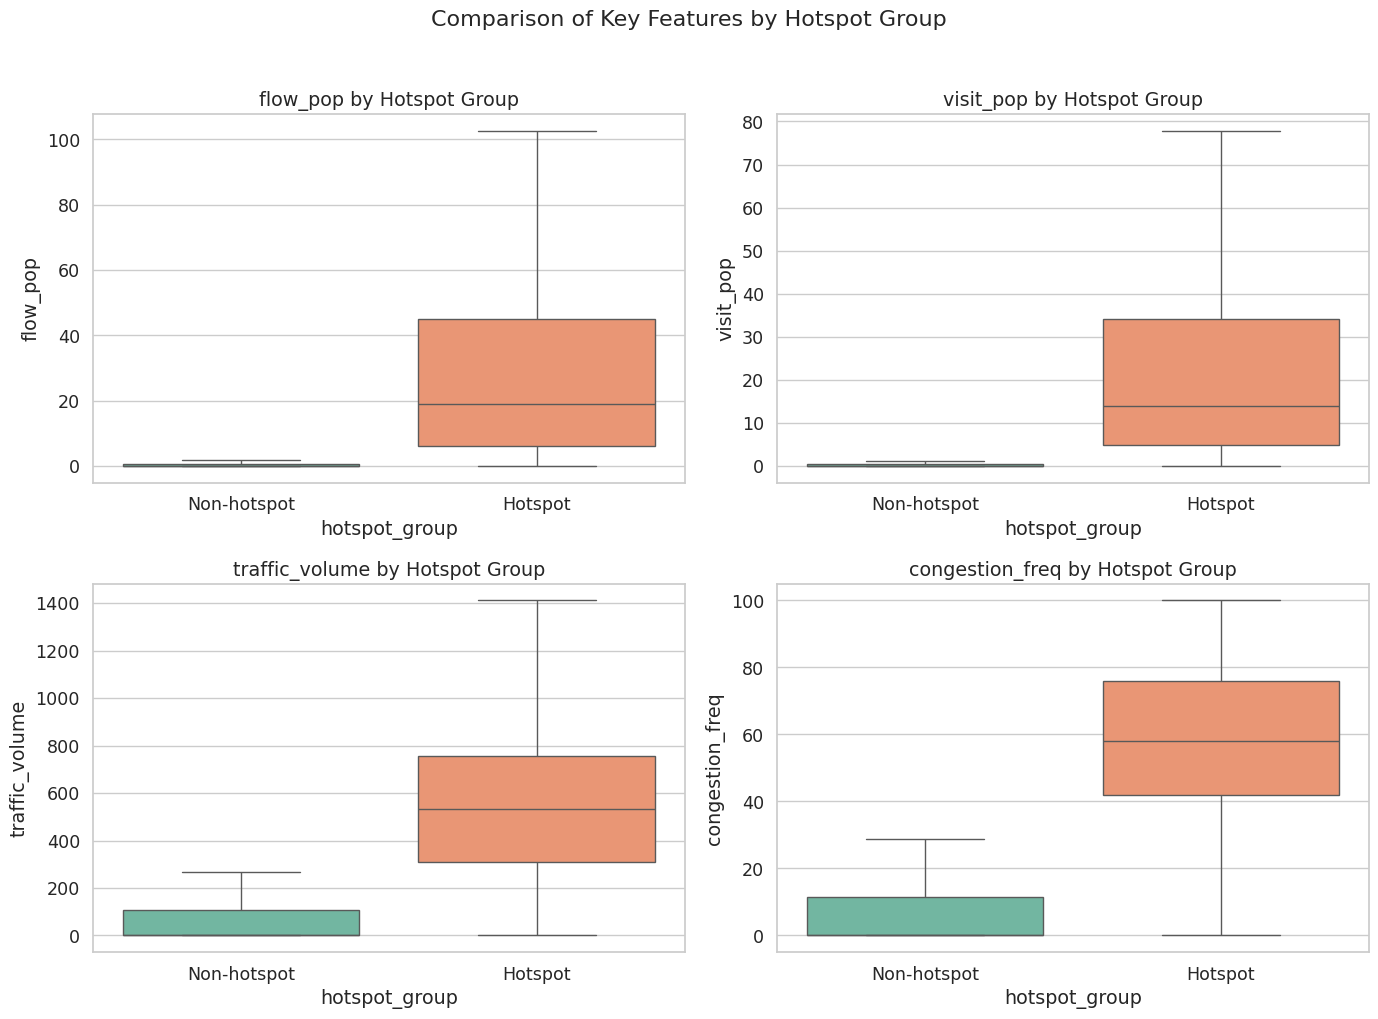

In [10]:
plot_cols = ["flow_pop", "visit_pop", "traffic_volume", "congestion_freq"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(
        data=analysis_df,
        x="hotspot_group",
        y=col,
        ax=axes[i],
        palette="Set2",
        showfliers=False
    )
    axes[i].set_title(f"{col} by Hotspot Group")

fig.suptitle("Comparison of Key Features by Hotspot Group", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

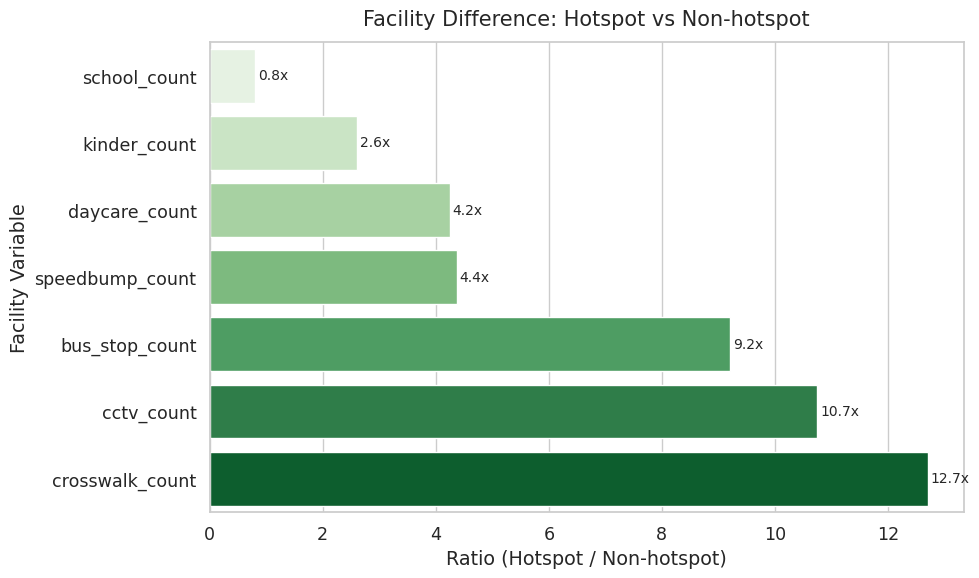

In [11]:
## 시설 변수 비교

facility_mean = analysis_df.groupby("hotspot_group")[facility_cols].mean().T
facility_mean["ratio_hotspot_to_non"] = (
    facility_mean["Hotspot"] / facility_mean["Non-hotspot"].replace(0, np.nan)
)
facility_mean.sort_values("ratio_hotspot_to_non", ascending=False)

facility_plot = facility_mean["ratio_hotspot_to_non"].sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=facility_plot.values,
    y=facility_plot.index,
    palette="Greens"
)

for i, v in enumerate(facility_plot.values):
    ax.text(v + 0.05, i, f"{v:.1f}x", va="center", fontsize=10)

plt.title("Facility Difference: Hotspot vs Non-hotspot", fontsize=15, pad=12)
plt.xlabel("Ratio (Hotspot / Non-hotspot)")
plt.ylabel("Facility Variable")

plt.tight_layout()
plt.show()

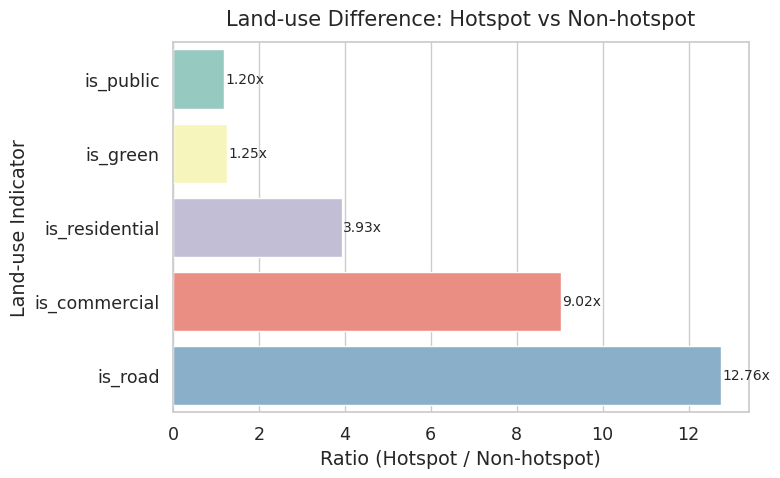

In [12]:
## 토지이용 변수 비교
landuse_mean = analysis_df.groupby("hotspot_group")[landuse_cols].mean().T
landuse_mean["ratio_hotspot_to_non"] = (
    landuse_mean["Hotspot"] / landuse_mean["Non-hotspot"].replace(0, np.nan)
)
landuse_mean.sort_values("ratio_hotspot_to_non", ascending=False)

plt.figure(figsize=(8, 5))

landuse_plot = landuse_mean["ratio_hotspot_to_non"].sort_values(ascending=True)

ax = sns.barplot(
    x=landuse_plot.values,
    y=landuse_plot.index,
    palette="Set3"
)

for i, v in enumerate(landuse_plot.values):
    ax.text(v + 0.03, i, f"{v:.2f}x", va="center", fontsize=10)

plt.title("Land-use Difference: Hotspot vs Non-hotspot", fontsize=15, pad=12)
plt.xlabel("Ratio (Hotspot / Non-hotspot)")
plt.ylabel("Land-use Indicator")

plt.tight_layout()
plt.show()

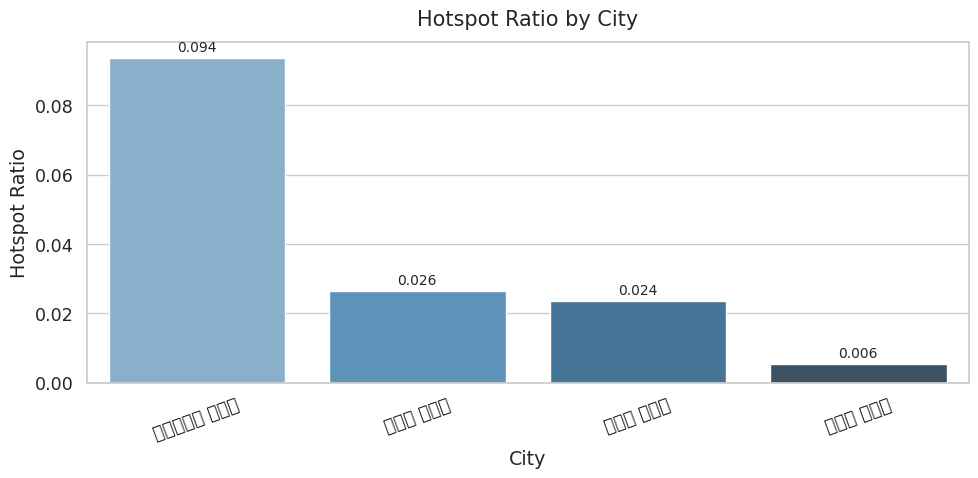

In [13]:
## 도시별 hotspot 분포 확인
city_hotspot_summary = analysis_df.groupby("city").agg(
    grid_count=("gid", "count"),
    hotspot_count=("is_hotspot", "sum"),
    hotspot_ratio=("is_hotspot", "mean"),
    mean_acc=("acc_cnt", "mean")
).reset_index().sort_values("hotspot_ratio", ascending=False)

city_hotspot_summary

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=city_hotspot_summary,
    x="city",
    y="hotspot_ratio",
    palette="Blues_d"
)

for i, v in enumerate(city_hotspot_summary["hotspot_ratio"]):
    ax.text(i, v + 0.001, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

plt.title("Hotspot Ratio by City", fontsize=15, pad=12)
plt.xlabel("City")
plt.ylabel("Hotspot Ratio")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Hotspot과 Non-hotspot의 사고 특성 비교

Hotspot과 Non-hotspot의 기본 사고 특성을 비교한 결과, 두 집단 간에는 매우 큰 차이가 나타났다.

> Hotspot은 전체 격자의 약 1.4%에 해당하는 1,447개 격자에 불과하지만, 이들 격자에서 전체 사고의 약 39%가 발생하였다.

- 또한 Hotspot 격자의 평균 사고 건수는 3.85로, Non-hotspot 격자의 평균 사고 건수(0.083) 대비 약 45배 이상 높은 수준을 보였다.

이는 교통사고가 도시 전반에 균등하게 분포하는 현상이 아니라, 일부 공간에서 집중적으로 발생하는 구조적 특성을 가진다는 것을 보여준다.

## 인구 이동 특성 비교

Hotspot 지역은 사람의 이동과 활동이 매우 활발한 공간적 특성을 보였다.

> 특히 방문인구(visit_pop)는 Non-hotspot 대비 약 20.6배,
서비스 인구(service_pop)는 약 19.5배,
유동인구(flow_pop)는 약 19.3배 높은 수준을 보였다.
또한 근무 인구(working_pop) 역시 약 16.4배 높은 수준으로 나타났다.

이는 교통사고 hotspot이 단순히 차량 통행량만 높은 지역이 아니라,
사람의 이동과 도시 활동이 집중되는 공간과 밀접하게 연결되어 있음을 시사한다.

## 교통 흐름 특성 비교

교통 흐름 관련 변수 역시 Hotspot에서 더 높은 수준을 보였다.

> Hotspot 지역의 교통량(traffic_volume)은 Non-hotspot 대비 약 4.2배 높았으며,
혼잡 시간(congestion_time) 역시 약 3.85배 높은 수준을 나타냈다.

- 이는 사고 집중 지역이 차량 이동이 많은 주요 교통 축 주변에서 형성될 가능성을 보여준다.

## 보행 및 교통 시설 비교

보행 및 교통 관련 시설 역시 Hotspot 지역에서 더 많이 분포하는 것으로 나타났다.

> 횡단보도(crosswalk_count)는 Non-hotspot 대비 약 12.7배,
CCTV는 약 10.7배,
버스정류장은 약 9.2배 높은 수준을 보였다.

- 이는 사고 hotspot이 보행 활동과 대중교통 이용이 활발한 생활권 중심 지역일 가능성을 보여준다.

## 토지 이용 특성 비교

토지 이용 특성을 비교한 결과, Hotspot 지역은 도로 및 상업 기능이 결합된 공간에서 더 높은 비율을 보였다.

> 특히 도로 지역(is_road)은 Non-hotspot 대비 약 12.7배,
상업 지역(is_commercial)은 약 9배 높은 수준으로 나타났다.

> 또한 주거 지역(is_residential) 역시 약 3.9배 높은 비율을 보여,
사고 hotspot은 단일 기능 공간이 아니라
주거·상업·교통 기능이 혼합된 도시 활동 중심 공간에서 형성될 가능성을 시사한다.

## Hotspot vs Non-hotspot 분석 종합 결과

본 분석을 통해 교통사고 hotspot은 다음과 같은 공간적 특성을 가지는 것으로 나타났다.

1. 사람의 이동과 도시 활동이 집중된 지역
2. 차량 통행량과 교통 혼잡이 높은 주요 교통 축
3. 보행 및 대중교통 활동이 활발한 생활권 중심 공간
4. 주거·상업·도로 기능이 결합된 복합 토지 이용 구조

특히 유동인구, 방문인구, 서비스 인구는 hotspot에서 약 16~20배 이상 높은 수준을 보였으며,
횡단보도와 버스정류장 등 보행 관련 시설 역시 hotspot에서 크게 높은 값을 나타냈다.

> 이는 교통사고가 단순한 무작위 사건이 아니라,
도시 활동 밀도와 교통 구조가 결합된 공간에서 집중적으로 발생할 가능성을 보여준다.